## Overview

This notebook builds a bidirectional LSTM RNN with a pretrained GloVe word embedding layer which predicts the sentiment (+ / - / neutral/mixed) of given text. The data source is google reviews of various restaurants 

GloVe data can be found here https://nlp.stanford.edu/projects/glove/

In [1]:
import pandas as pd
from tqdm import tqdm
import torch
import torch.nn as nn
import time
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
import numpy as np

import random

def set_seed(seed):
    torch.manual_seed(seed)
    
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)  # if using multi-GPU.
        
    np.random.seed(seed)  # Numpy module.
    random.seed(seed)  # Python's random module.
    
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.enabled = False

set_seed(1000)

# Set this for autonaming of plots
rest_type = 'veg'

In [2]:
# Import pre-split datasets for train, val and test cycles
df_train = pd.read_csv('./data/veg-train.csv')
df_val = pd.read_csv('./data/veg-val.csv')
df_test = pd.read_csv('./data/veg-test.csv')

#df_train = pd.read_csv('./data/midwest/big-train-sampled.csv')
#df_val = pd.read_csv('./data/midwest/big-val-sampled.csv')
#df_test = pd.read_csv('./data/midwest/big-test-sampled.csv')

## Prepare the text

- Turn into lowercase
- Tokenize the inputs
- Create column for + / - / neutral review labels

In [3]:
import re
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

def lemmatize_tokens(tokens, lemmatizer, pos_tags=False):
    lemmatized_text = []

    for token in tokens:
        lemma = lemmatizer.lemmatize(token)
        lemmatized_text.append(lemma)
        
    return lemmatized_text

def preprocess_text(text):
    # Maybe there's a better way to do this, but it gets hung up on reviews that are just integers 
    # I don't know why someone would leave such a review but there are a few
    text = str(text) 

    # This appears in some reviews
    text = text.replace('(Translated by Google)', ' ')
    text = text.replace('\n', ' ')

    # Make lowercase and remove puncuation 
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)

    tokens = word_tokenize(text)

    return tokens
    #return lemmatize_tokens(tokens=tokens, lemmatizer=WordNetLemmatizer())

## Get stopwords from nltk
# this doesn't actually use the stopwords
stop_words = list(stopwords.words('english')) 

df_train['tokens'] = df_train['text'].apply(preprocess_text)
df_val['tokens'] = df_val['text'].apply(preprocess_text)
df_test['tokens'] = df_test['text'].apply(preprocess_text)

In [4]:
def pnn(n):
    if n in {1,2}: return 0 # negative
    elif n in {4,5}: return 2 # positive
    else: return 1 # "neutral"

def minus1(n):
    return n-1
    
df_train['pnn'] = df_train['rating'].apply(pnn)
df_val['pnn'] = df_val['rating'].apply(pnn)
df_test['pnn'] = df_test['rating'].apply(pnn)

In [5]:
## Check the data
print('Train set sample')
print(df_train.sample(5))
print()

print('Eval set sample')
print(df_val.sample(5))
print()

print('Test set sample')
print(df_test.sample(5))
print()

Train set sample
        rating                                               text  \
359462       3  Rude customer service!!! No napkins in bag!! G...   
456415       2        30 min in drive-thru and order still wrong!   
227730       4  This could have gone better. To start all in a...   
148300       5            This place will make your tummy smile 😀   
352580       3                                       Slow service   

                                                   tokens  pnn  
359462  [rude, customer, service, no, napkins, in, bag...    1  
456415  [30, min, in, drivethru, and, order, still, wr...    0  
227730  [this, could, have, gone, better, to, start, a...    2  
148300      [this, place, will, make, your, tummy, smile]    2  
352580                                    [slow, service]    1  

Eval set sample
       rating                                               text  \
5563        5      Love this establishment location, cleanliness   
68433       3  (Translate

## Create embedding layer

- Create dictionary of words in descent order of prevalence from the training data
- Create an embedding matrix using the 100-d glove layer
- Can be skipped for continuing training (see last cell for loading code)


In [16]:
# This can be slow
df_dict = dict()
for review in df_train['tokens']:
    for word in review:
        if word in df_dict:
            df_dict[word] += 1

        else: 
            df_dict[word] = 1

# sort by most common appearing words
df_dict = {key: value for key, value in df_dict.items() if value > 1}
df_dict = list(dict(sorted(df_dict.items(), key=lambda item: item[1], reverse=True)))

# Create vocab as dict word:idx ordered by most common appearance
vocab = dict()
i = 1
vocab_max_len = 20000

for word in df_dict:
    if i == vocab_max_len:
        break
        
    vocab[word] = i
    i += 1

In [17]:
# This will create the embedding matrix
# This takes in a dictionary, which should be influenced by the review data
def load_glove_embeddings(glove_file, dictionary):
    embeddings = {}
    
    with open(glove_file, 'r', encoding='utf-8') as f:
        for line in f:
            values = line.split()
            word = values[0]
            if word in dictionary:
                vector = np.asarray(values[1:], dtype='float32')
                embeddings[word] = vector

    return embeddings

def create_embedding_matrix(glove_embeddings, vocab):
    embedding_dim = glove_len
    num_embeddings = len(vocab) + 1
    embedding_matrix = np.zeros((num_embeddings, embedding_dim))
    
    for word, idx in vocab.items():
            
        if word not in glove_embeddings:
            continue
            
        embedding_vector = glove_embeddings.get(word)
        if embedding_vector is not None:
            embedding_matrix[idx] = embedding_vector

        
            
    return torch.tensor(embedding_matrix, dtype=torch.float32)

## Set directory of glove file and load the embeddings
glove_file = './glove/glove.6B.100d.txt' 
glove_embeddings = load_glove_embeddings(glove_file, vocab)

## Set dim of GloVe vectors (we'll use the 50d)
glove_len = len(glove_embeddings['the'])

# Create embedding matrix
embedding_matrix = create_embedding_matrix(glove_embeddings, vocab)

vocab_size, embedding_dim = list(embedding_matrix.size())
print(vocab_size, embedding_dim)

20000 100


In [18]:
# Check that the matrix is the right thing
for index, (key, value) in enumerate(vocab.items()):
        if index < 5:
            print(value, key)
            print()

            print('embedding mat')
            print(embedding_matrix[value])
            
            print('glove emb')
            print(glove_embeddings[key])
            print()
        else:
            break

1 the

embedding mat
tensor([-0.0382, -0.2449,  0.7281, -0.3996,  0.0832,  0.0440, -0.3914,  0.3344,
        -0.5755,  0.0875,  0.2879, -0.0673,  0.3091, -0.2638, -0.1323, -0.2076,
         0.3340, -0.3385, -0.3174, -0.4834,  0.1464, -0.3730,  0.3458,  0.0520,
         0.4495, -0.4697,  0.0263, -0.5415, -0.1552, -0.1411, -0.0397,  0.2828,
         0.1439,  0.2346, -0.3102,  0.0862,  0.2040,  0.5262,  0.1716, -0.0824,
        -0.7179, -0.4153,  0.2033, -0.1276,  0.4137,  0.5519,  0.5791, -0.3348,
        -0.3656, -0.5486, -0.0629,  0.2658,  0.3020,  0.9977, -0.8048, -3.0243,
         0.0125, -0.3694,  2.2167,  0.7220, -0.2498,  0.9214,  0.0345,  0.4674,
         1.1079, -0.1936, -0.0746,  0.2335, -0.0521, -0.2204,  0.0572, -0.1581,
        -0.3080, -0.4162,  0.3797,  0.1501, -0.5321, -0.2055, -1.2526,  0.0716,
         0.7056,  0.4974, -0.4206,  0.2615, -1.5380, -0.3022, -0.0734, -0.2831,
         0.3710, -0.2522,  0.0162, -0.0171, -0.3898,  0.8742, -0.7257, -0.5106,
        -0.5203, -0

## Create LSTM class

- Autosend to GPU/CPU

In [19]:
class LSTMModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size, num_layers, output_size, embedding_matrix):
        super(LSTMModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.embedding.weight.data.copy_(embedding_matrix) #load the pretrained embeddings.
        
        # Freeze parameters from glove embedding matrix
        self.embedding.weight.requires_grad = False 

        # bidirectional LSTM
        self.lstm = nn.LSTM(embedding_dim, hidden_size, num_layers, dropout=0.3, batch_first=True, bidirectional=True) 
        self.fc = nn.Linear(hidden_size * 2, output_size) 

    def forward(self, x):
        embedded = self.embedding(x)
        out, _ = self.lstm(embedded)
        out = self.fc(out[:, -1, :])
        
        return out


In [20]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print('Device:', device)

# Set model parameters
hidden_size = 196 # Tried larger size here, not sure
num_layers = 2
output_size = 3  # Number of output classes: positive/negative/neutral

## Idea is to add an attention layer
model = LSTMModel(vocab_size, embedding_dim, hidden_size, num_layers, output_size, embedding_matrix)
model.to(device)

Device: cuda


LSTMModel(
  (embedding): Embedding(20000, 100)
  (lstm): LSTM(100, 196, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (fc): Linear(in_features=392, out_features=3, bias=True)
)

In [21]:
from torchinfo import summary
summary(model)

Layer (type:depth-idx)                   Param #
LSTMModel                                --
├─Embedding: 1-1                         (2,000,000)
├─LSTM: 1-2                              1,392,384
├─Linear: 1-3                            1,179
Total params: 3,393,563
Trainable params: 1,393,563
Non-trainable params: 2,000,000

## Create datasets and prepare data

- Turn text data into vectors containing the index of the embedded words
- Prepare datasets and dataloaders
- Calculate weightings for loss function based on class imbalences
- Create auxillary functions for performance metrics

In [22]:
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

class SentimentDataset(Dataset):
    def __init__(self, sequences, labels):
        self.sequences = sequences
        self.labels = labels

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        return self.sequences[idx], self.labels[idx]

In [23]:
# Converts a string to vocab indices, and pads/truncates all reviews to be 50 tokens
def stringerizer(tokens, max_length=64):
    ids = []
    for word in tokens:
        if (word not in glove_embeddings) or (word not in vocab):
            continue

        else: ids.append(vocab[word])

    return ids[:max_length] + [0] * (max_length - len(ids))

In [24]:
X_train = []
y_train = df_train['pnn']

X_val = []
y_val = torch.tensor(df_val['pnn'].tolist(), dtype=torch.long)

X_test = []
y_train = torch.tensor(df_test['pnn'], dtype=torch.long)

for review in df_train['tokens']:
    X_train.append(stringerizer(review, max_length=128))

for review in df_val['tokens']:
    X_val.append(stringerizer(review, max_length=128))

for review in df_test['tokens']:
    X_test.append(stringerizer(review, max_length=128))

X_train = torch.tensor(X_train, dtype=torch.long)
X_val = torch.tensor(X_val, dtype=torch.long)
X_test = torch.tensor(X_test, dtype=torch.long)

train_dataset = SentimentDataset(X_train, df_train['pnn'])
val_dataset = SentimentDataset(X_val, df_val['pnn'])
test_dataset = SentimentDataset(X_test, df_test['pnn'])

In [25]:
import seaborn as sns
import datetime
import matplotlib.pyplot as plt

def plot_confusion_matrix(cm, classes, title='Confusion Matrix', cmap=plt.cm.Blues):
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, xticklabels=classes, yticklabels=classes)
    
    plt.title(title)
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    
    current_time = datetime.datetime.now()
    file_name = f'./sshots/model-{rest_type}-{current_time.strftime("%Y-%m-%d--%H%m")}.png'
    plt.savefig(file_name)
    
    plt.show()
    return

def runtime(start_time):
    end_time = time.time()
    s = end_time - start_time

    h = s // 3600
    s = s - 3600*h

    m = s // 60
    s = s - 60*m

    print(f'Total runtime: {int(h)} hr {int(m)} min {s:.1f} sec')
    return 

In [26]:
from sklearn.utils import class_weight

# Ratings are not evenly distributed, this creates class weights
def calculate_class_weights(labels):
    class_weights = class_weight.compute_class_weight('balanced', classes=np.unique(labels), y=labels)
    return torch.tensor(class_weights, dtype=torch.float)

In [27]:
batch_size = 256
learning_rate = .001
weight_decay = .01

train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size)

# Define loss function and optimizer
class_weights = calculate_class_weights(df_train['pnn'].tolist()).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = optim.Adam(model.parameters(), lr=learning_rate)

print('Class weights:', class_weights)

Class weights: tensor([1.6883, 2.4690, 0.4993], device='cuda:0')


## Model evaluation

- Create primary train/val/test cycle with early stopping
- F1 score is used as metric for stopping criteria
- Test cycle prints a confusion matrix and writes the probabilities of the predictions to the appropriate df

In [28]:
def evaluate_model(model, dataloader):
    # Put in evaluation mode
    print('Evaluating...', end='\r')
    model.eval()
    
    all_preds, all_labels = [], []
    
    with torch.no_grad():
        for X, y in dataloader:
            X = X.to(device)
            y = y.to(device)

            output = model(X)
            
            pred_labels = torch.argmax(output, dim=1)
            
            all_preds.extend(pred_labels.cpu().numpy())
            all_labels.extend(y.cpu().numpy())
    
    ## Accuracy and F1 used to determine early exit
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='weighted')

    return acc, f1

In [29]:
def early_stopping(model, train_dataloader, val_dataloader, optimizer, epochs=100, patience=5, max_grad_norm=1.0, device='cuda'):
    m_name = f'./saved-models/LSTM-{rest_type}.pth'
    
    # Keep track of some data
    start_time = time.time()
    accs, f1s = [], []

    # Learning rate scheduler
    # Cosine annealing works really well !
    
    #scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1) 
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=100)

    # Set best value as low as possible to start
    best_val_f1 = -np.inf
    patience_counter = 0

    for epoch in range(epochs):
        # Put model in train mode
        model.train()
        train_loss = 0
    
        for X, y in tqdm(train_dataloader, desc=f"Epoch {epoch + 1}"):
            X = X.to(device)
            y = y.to(device)

            optimizer.zero_grad()
            
            ## Evaluate model at the inputs
            output = model(X)
            
            ## Evaluate loss and backpropogate
            loss = criterion(output, y)
            loss.backward()

            train_loss += loss.item()

            ## Clip gradient
            #torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)

            ## Stepforward the optimizer and scheduler
            optimizer.step()
            scheduler.step()

        # Keep track of loss
        loss = train_loss / len(train_dataloader)
        
        # Validation cycle
        val_acc, val_f1 = evaluate_model(model=model, dataloader=val_dataloader)
        
        accs.append(val_acc)
        f1s.append(val_f1)

        # Keep track of progress
        print(f'Train loss: {loss:.5f} | Val acc: {100*val_acc:.2f}%, F1 {val_f1:.5f}')
        
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            patience_counter = 0
            
            # Save the best model
            torch.save(model.state_dict(), m_name)
            print('--New best--')
            
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print('Early stopping triggered')
                break 

    # Print total runtime
    runtime(start_time)

    # Load the best model and return it
    model.load_state_dict(torch.load(m_name))
    return model

In [30]:
model = early_stopping(model=model, 
                       train_dataloader=train_dataloader, 
                       val_dataloader=val_dataloader, 
                       optimizer=optimizer, 
                       epochs=500, 
                       patience=5,
                       max_grad_norm=1.0,
                       device=device)

Epoch 1: 100%|██████████████████████████████████████████████| 1876/1876 [03:23<00:00,  9.23it/s]


Train loss: 0.89549 | Val acc: 73.28%, F1 0.76405
--New best--


Epoch 2: 100%|██████████████████████████████████████████████| 1876/1876 [03:23<00:00,  9.21it/s]


Train loss: 0.63845 | Val acc: 76.57%, F1 0.78763
--New best--


Epoch 3: 100%|██████████████████████████████████████████████| 1876/1876 [03:24<00:00,  9.20it/s]


...

Epoch 56: 100%|█████████████████████████████████████████████| 1876/1876 [03:21<00:00,  9.31it/s]


Train loss: 0.18523 | Val acc: 87.82%, F1 0.88373


Epoch 57: 100%|█████████████████████████████████████████████| 1876/1876 [03:20<00:00,  9.36it/s]


Train loss: 0.18468 | Val acc: 88.09%, F1 0.88558
Early stopping triggered
Total runtime: 3 hr 23 min 25.5 sec


/tmp/ipykernel_2130512/2563357210.py:72: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f'./saved-models/LSTM-{rest_type}.pth'))


100%|█████████████████████████████████████████████████████████| 230/230 [00:06<00:00, 36.88it/s]


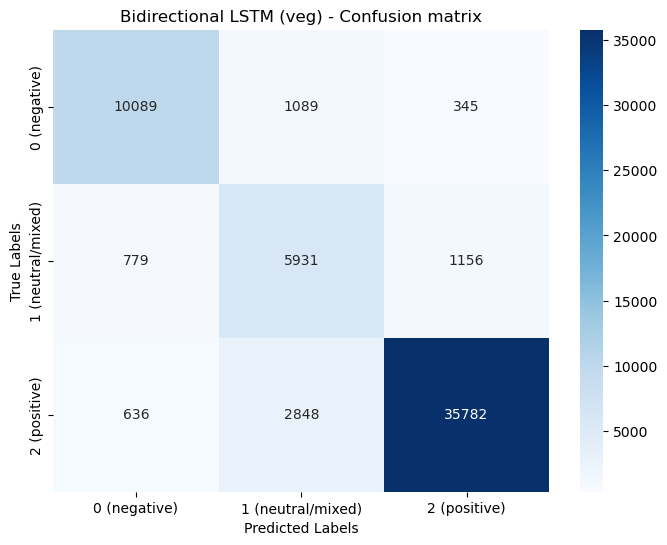

Test acc: 88.32%, F1 0.88769


In [31]:
# Final prediction on testing set
def make_prediction(model, dataloader):
    model.eval()
    
    all_probs, all_preds, all_labels = [], [], []
    
    with torch.no_grad():
        for X, y in tqdm(dataloader):
            X = X.to(device)
            y = y.to(device)
            
            output = model(X)

            pred_labels = torch.argmax(output, dim=1)
            
            all_preds.extend(pred_labels.cpu().numpy())
            all_labels.extend(y.cpu().numpy())

            # Keep probabilities
            probs = torch.softmax(output, dim=1).cpu().numpy()
            all_probs.extend(probs)

    plot_confusion_matrix(cm=confusion_matrix(np.array(df_test['pnn']), np.array(all_preds)), 
                            classes=['0 (negative)', '1 (neutral/mixed)', '2 (positive)'], 
                            title=f'Bidirectional LSTM ({rest_type}) - Confusion matrix')

    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='weighted')
    
    return all_probs, acc, f1 

# Predict
probs, acc, f1 = make_prediction(model=model, dataloader=test_dataloader)
print(f'Test acc: {100*acc:.2f}%, F1 {f1:.5f}')

In [55]:
# Write probs column and save df
def probs_to_columns(probs):
    neg, neut, pos, pred = [], [], [], []
    for row in probs:
        neg.append(row[0])
        neut.append(row[1])
        pos.append(row[2])
        pred.append(np.argmax(row).item())
        
    return neg, neut, pos, pred
        
neg, mixed, pos, pred = probs_to_columns(probs)

df_test['lstm-neg'] = neg
df_test['lstm-mixed'] = mixed
df_test['lstm-pos'] = pos
df_test['lstm-pred'] = pred

df_test.to_csv('./data/veg-test.csv', index=False)

## Save/load embedding layers
- Can be recomputed (there is no random processes), but is time consuming.

In [32]:
import pickle

def save_dictionary_pickle(dictionary, filename):
    """Saves a dictionary to a pickle file."""
    with open(filename, 'wb') as f:  # 'wb' for binary write
        pickle.dump(dictionary, f)

def load_dictionary_pickle(filename):
    """Loads a dictionary from a pickle file."""
    with open(filename, 'rb') as f:  # 'rb' for binary read
        return pickle.load(f)

save_dictionary_pickle(embedding_matrix, f'{rest_type}-embd-mat.pkl')